# Plots required for implementation chapter.

In [ ]:
%load_ext autoreload
%autoreload 2

## Implmentation Dissertation Plots

In [3]:
from utils.agent import generate_agent_options
import numpy as np

In [4]:
rng = np.random.default_rng(123)
algorithm_seeds = rng.integers(0, 10**6, size=10)

In [5]:
num_agents = 100
city_starts = ['S1', 'S2', 'S3', 'S4']
seed = algorithm_seeds[0]

In [6]:
starts =  generate_agent_options(
            options=city_starts,
            num_agents=num_agents,
            seed=seed,
            on=True,
        )

walking = generate_agent_options(
            options=[1, 2, 3],
            num_agents=num_agents,
            seed=seed,
            on=True,
            default=1,
            weights=[0.6, 0.3, 0.1])

delays = generate_agent_options(
            options=[0, 1, 2],
            num_agents=num_agents,
            seed=seed,
            on=True,
            default=0,
            weights=[0.4, 0.4, 0.2],
)

compliance = generate_agent_options(
            options=[0, 1],
            num_agents=num_agents,
            seed=seed,
            on=True,
            default=1,
            weights=[(1 - 0.8), 0.8],
        )


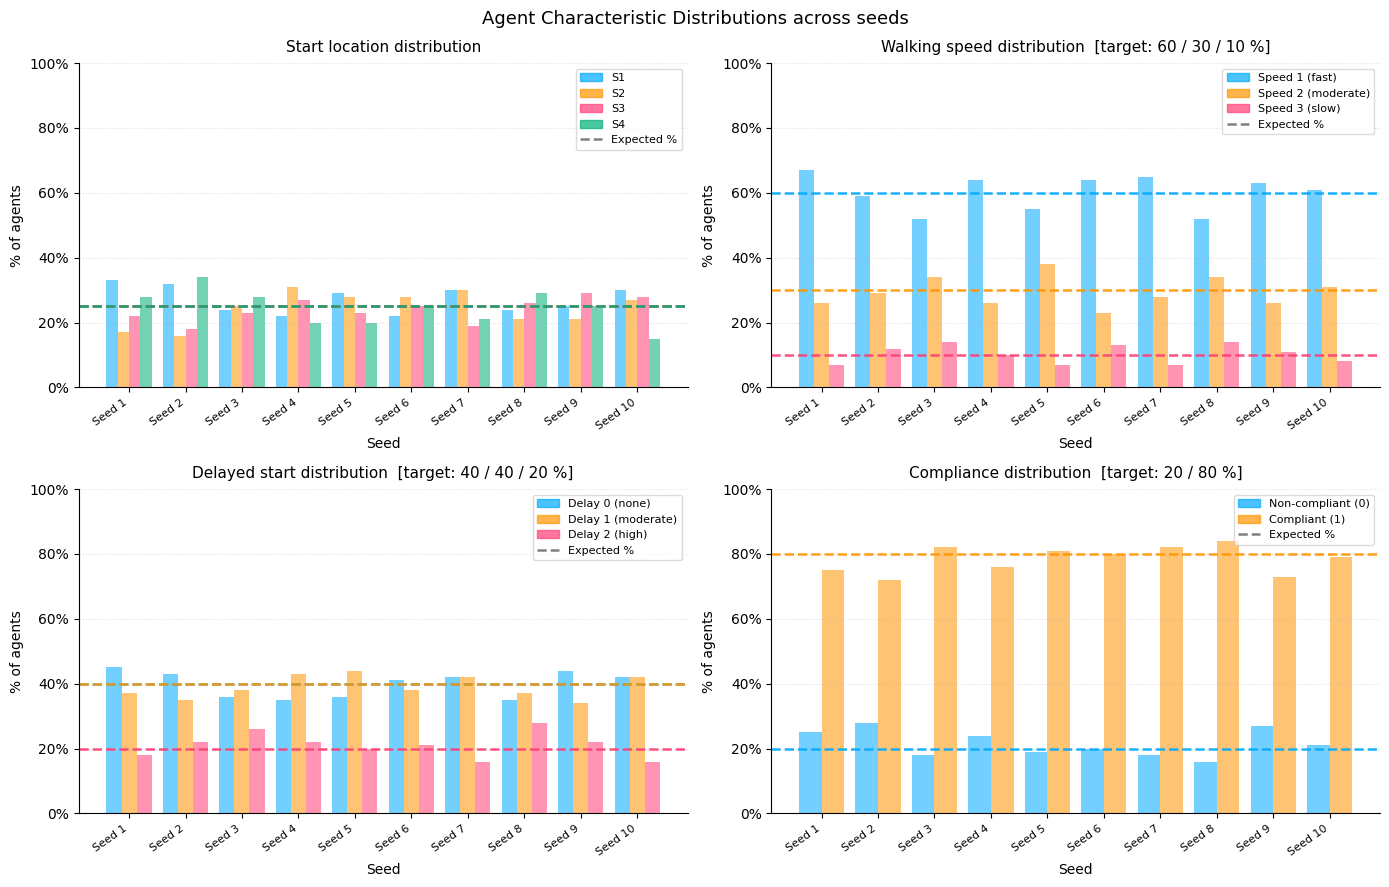

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ── config ───────────────────────────────────────────────────────────────────
NUM_AGENTS   = 100
NUM_SEEDS    = 10
CITY_STARTS  = ["S1", "S2", "S3", "S4"]
BASE_SEED    = 42

rng = np.random.default_rng(123)
seeds = rng.integers(0, 10**6, size=10)

# ── collect distributions across seeds ───────────────────────────────────────
results = {
    "starts":     [],   # list of lists
    "walking":    [],
    "delays":     [],
    "compliance": [],
}

for seed in seeds:
    results["starts"].append(
        generate_agent_options(
            options=city_starts,
            num_agents=num_agents,
            seed=seed,
            on=True,
        ))
    results["walking"].append(
        generate_agent_options(
            options=[1, 2, 3],
            num_agents=num_agents,
            seed=seed,
            on=True,
            default=1,
            weights=[0.6, 0.3, 0.1]))
    results["delays"].append(
        generate_agent_options(
            options=[0, 1, 2],
            num_agents=num_agents,
            seed=seed,
            on=True,
            default=0,
            weights=[0.4, 0.4, 0.2],
))
    results["compliance"].append(
        generate_agent_options(
            options=[0, 1],
            num_agents=num_agents,
            seed=seed,
            on=True,
            default=1,
            weights=[(1 - 0.8), 0.8],
        ))

# ── helper: compute % per category per seed ───────────────────────────────────
def to_pct(data, categories):
    out = {c: [] for c in categories}
    for seed_data in data:
        total = len(seed_data)
        for c in categories:
            out[c].append(100 * seed_data.count(c) / total)
    return out

starts_pct     = to_pct(results["starts"],     CITY_STARTS)
walking_pct    = to_pct(results["walking"],    [1, 2, 3])
delays_pct     = to_pct(results["delays"],     [0, 1, 2])
compliance_pct = to_pct(results["compliance"], [0, 1])

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Agent Characteristic Distributions across seeds", fontsize=13, y=0.98)

PALETTE   = ["#00A9FE", "#FF9501", "#FF3E75", "#00AE77"]
BAR_ALPHA = 0.55
LINE_W    = 1.8

def grouped_bars(ax, categories, pct_dict, expected, x_labels,
                 title, ylabel, x_title):
    n_cats  = len(categories)
    n_seeds = NUM_SEEDS
    width   = 0.8 / n_cats
    x       = np.arange(n_seeds)

    for i, (cat, colour) in enumerate(zip(categories, PALETTE)):
        vals   = pct_dict[cat]
        offset = (i - n_cats / 2 + 0.5) * width
        bars   = ax.bar(x + offset, vals, width,
                        color=colour, alpha=BAR_ALPHA,
                        label=str(x_labels[i]))
        # expected dashed line
        ax.axhline(expected[i], color=colour, linestyle="--",
                   linewidth=LINE_W, alpha=0.9)

    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel(x_title, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Seed {i+1}" for i in range(n_seeds)],
                       rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    # legend: solid square = actual, dashed line = expected
    cat_handles = [mpatches.Patch(color=PALETTE[i], alpha=0.7,
                                  label=str(x_labels[i]))
                   for i in range(n_cats)]
    exp_handle  = plt.Line2D([0], [0], color="grey", linestyle="--",
                             linewidth=LINE_W, label="Expected %")
    ax.legend(handles=cat_handles + [exp_handle],
              fontsize=8, loc="upper right", framealpha=0.7)

# ── panel 1: start locations (equal split expected) ──────────────────────────
equal_pct = [25.0] * 4
grouped_bars(axes[0, 0],
             CITY_STARTS, starts_pct, equal_pct,
             x_labels=CITY_STARTS,
             title="Start location distribution",
             ylabel="% of agents",
             x_title="Seed")

# ── panel 2: walking speed ────────────────────────────────────────────────────
grouped_bars(axes[0, 1],
             [1, 2, 3], walking_pct, [60.0, 30.0, 10.0],
             x_labels=["Speed 1 (fast)", "Speed 2 (moderate)", "Speed 3 (slow)"],
             title="Walking speed distribution  [target: 60 / 30 / 10 %]",
             ylabel="% of agents",
             x_title="Seed")

# ── panel 3: delayed starts ───────────────────────────────────────────────────
grouped_bars(axes[1, 0],
             [0, 1, 2], delays_pct, [40.0, 40.0, 20.0],
             x_labels=["Delay 0 (none)", "Delay 1 (moderate)", "Delay 2 (high)"],
             title="Delayed start distribution  [target: 40 / 40 / 20 %]",
             ylabel="% of agents",
             x_title="Seed")

# ── panel 4: compliance ───────────────────────────────────────────────────────
grouped_bars(axes[1, 1],
             [0, 1], compliance_pct, [20.0, 80.0],
             x_labels=["Non-compliant (0)", "Compliant (1)"],
             title="Compliance distribution  [target: 20 / 80 %]",
             ylabel="% of agents",
             x_title="Seed")

plt.tight_layout()

## Other random checks 

In [ ]:
folder = 'outputs/runs/'

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
baseline_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
}

In [ ]:
from utils.comparison_metrics import extract_results

results = extract_results(baseline_files['Grid'])

In [ ]:
seed_results = []

for seed in results['greedy']['solutions']:
    start_points = [agent.start_point for agent in seed.values()]
    seed_results.append(start_points)

In [ ]:
import pandas as pd
from collections import Counter

def count_agents_per_start(seed_results: list) -> pd.DataFrame:
    rows = []
    for seed_idx, seed in enumerate(seed_results):
        counts = Counter(seed)
        counts['Seed'] = seed_idx + 1
        rows.append(counts)
    
    df = pd.DataFrame(rows).fillna(0).set_index('Seed')
    df = df.astype(int)
    
    # sort columns
    df = df.reindex(sorted(df.columns), axis=1)
    
    return df

df = count_agents_per_start(seed_results)
print(df.to_string())

      S1  S2  S3  S4
Seed                
1     33  17  22  28
2     32  16  18  34
3     24  25  23  28
4     22  31  27  20
5     29  28  23  20
6     22  28  25  25
7     30  30  19  21
8     24  21  26  29
9     25  21  29  25
10    30  27  28  15


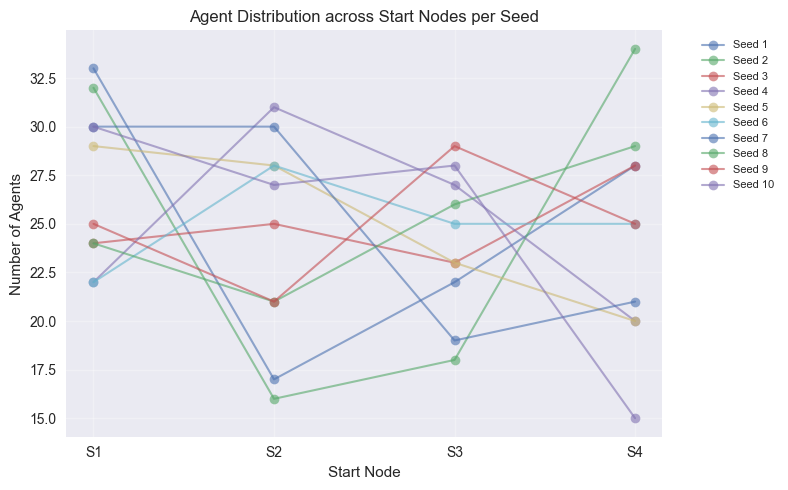

In [ ]:
import matplotlib.pyplot as plt

def plot_agent_start_distribution(seed_results: list) -> None:
    start_nodes = sorted(set(s for seed in seed_results for s in seed))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for seed_idx, seed in enumerate(seed_results):
        counts = Counter(seed)
        values = [counts.get(s, 0) for s in start_nodes]
        ax.plot(start_nodes, values, marker='o', linewidth=1.5, 
                alpha=0.6, label=f'Seed {seed_idx + 1}')
    
    ax.set_xlabel("Start Node")
    ax.set_ylabel("Number of Agents")
    ax.set_title("Agent Distribution across Start Nodes per Seed")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_agent_start_distribution(seed_results)